In [ ]:
# pip install alpaca-trade-api pandas
import pandas as pd
import alpaca_trade_api as tradeapi

# ---- Your Paper API credentials ----
API_KEY = "PK3GHI019QPFWL3YE6WH"
API_SECRET = "mbz1rMmxI8QJcfuBnBiwvX6NKbiiNvUDOZqDgVyF"
BASE_URL = "https://paper-api.alpaca.markets"

# # ---- Create API object ----
# api = tradeapi.REST(API_KEY, API_SECRET, base_url=BASE_URL)

# # ---- Date range (US Eastern time) ----
# start = "2025-03-01T09:30:00-05:00"
# end   = "2025-06-30T16:00:00-04:00"

# # ---- Get 1-minute bars for SPY ----
# bars = api.get_bars(
#     symbol="SPY",
#     timeframe="1Min",
#     start=start,
#     end=end,
#     adjustment="raw"
# ).df

# # ---- Save to CSV ----
# bars.to_csv("SPY_1m_Mar-Jun2025.csv")
# print(bars.head(), "\n")
# print(f"Saved {len(bars):,} rows from {bars.index.min()} to {bars.index.max()}")


                            close    high     low  trade_count    open  \
timestamp                                                                
2025-03-03 09:00:00+00:00  594.15  594.50  593.88          136  593.88   
2025-03-03 09:01:00+00:00  594.25  594.25  594.16           60  594.16   
2025-03-03 09:02:00+00:00  594.31  594.34  594.16           52  594.18   
2025-03-03 09:03:00+00:00  594.23  594.37  594.22           77  594.32   
2025-03-03 09:04:00+00:00  594.22  594.22  594.18           39  594.20   

                           volume        vwap  
timestamp                                      
2025-03-03 09:00:00+00:00    3103  594.205383  
2025-03-03 09:01:00+00:00    1122  594.215765  
2025-03-03 09:02:00+00:00    2579  594.246282  
2025-03-03 09:03:00+00:00    1892  594.248311  
2025-03-03 09:04:00+00:00    6952  594.217015   

Saved 71,973 rows from 2025-03-03 09:00:00+00:00 to 2025-06-30 20:00:00+00:00


In [5]:
import pandas_ta as ta

In [6]:
import pandas as pd
import pandas_ta as ta

df = pd.read_csv("SPY_1m_Mar-Jun2025.csv", parse_dates=["timestamp"], index_col="timestamp")
df.columns = [c.lower() for c in df.columns]

# Compute Ichimoku (default params: 9, 26, 52)
ichi = ta.ichimoku(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    tenkan=9,
    kijun=26,
    senkou=52
)

# The result is a tuple of DataFrames (conversion/base/leading/lagging)
ichi_df = pd.concat(ichi, axis=1)
df = pd.concat([df, ichi_df], axis=1)

print(df.tail(10))


                           close  high  low  trade_count  open  volume  vwap  \
2025-07-23 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-07-24 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-07-25 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-07-28 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-07-29 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-07-30 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-07-31 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-08-01 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-08-04 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   
2025-08-05 20:00:00+00:00    NaN   NaN  NaN          NaN   NaN     NaN   NaN   

                           ISA_9  ISB_26  ITS_9  IKS_26  ICS_26     ISA_9  \
2025-07-23 20:00:00+00:00    NaN     NaN  

<Axes: >

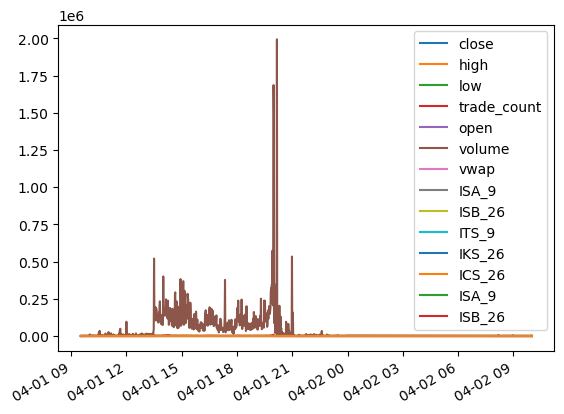

In [10]:
df.loc["2025-04-01 09:30:00":"2025-04-02 10:00:00"].plot()

In [12]:
import pandas as pd
import pandas_ta as ta
import plotly.graph_objects as go

# Load your data
df = pd.read_csv("SPY_1m_Mar-Jun2025.csv", parse_dates=["timestamp"])
df.columns = [c.lower() for c in df.columns]

# Compute Ichimoku (unpack tuple)
conv_base, span_ab, lagging = ta.ichimoku(
    high=df['high'], low=df['low'], close=df['close'],
    tenkan=9, kijun=26, senkou=52
)

# Rename columns for clarity
conv_base.columns = ['tenkan_sen', 'kijun_sen']
span_ab.columns = ['senkou_a', 'senkou_b']
lagging.columns = ['chikou_span']

# Merge into main df
df = pd.concat([df, conv_base, span_ab, lagging], axis=1)

# --- Plot ---
fig = go.Figure()

# Price candles
fig.add_trace(go.Candlestick(
    x=df['timestamp'], open=df['open'], high=df['high'],
    low=df['low'], close=df['close'],
    name='Price', increasing_line_color='green', decreasing_line_color='red'
))

# Tenkan/Kijun
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['tenkan_sen'], line=dict(color='blue'), name='Tenkan-sen'))
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['kijun_sen'], line=dict(color='red'), name='Kijun-sen'))

# Chikou Span
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['chikou_span'], line=dict(color='purple'), name='Chikou Span'))

# Cloud (fill between Span A and Span B)
fig.add_trace(go.Scatter(
    x=df['timestamp'], y=df['senkou_a'], line=dict(color='rgba(0,0,0,0)'), showlegend=False
))
fig.add_trace(go.Scatter(
    x=df['timestamp'], y=df['senkou_b'], line=dict(color='rgba(0,0,0,0)'), fill='tonexty',
    fillcolor='rgba(0,255,0,0.2)', showlegend=False
))

# Layout
fig.update_layout(
    title="SPY Ichimoku Cloud (1-Minute)",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    hovermode="x unified",
    height=800
)

fig.show()


ValueError: not enough values to unpack (expected 3, got 2)

In [13]:
import pandas as pd
import pandas_ta as ta
import plotly.graph_objects as go

# Load your SPY 1-min data
df = pd.read_csv("SPY_1m_Mar-Jun2025.csv", parse_dates=["timestamp"])
df.columns = [c.lower() for c in df.columns]

# Compute Ichimoku with chikou span included
conv_base, span_ab, lagging = ta.ichimoku(
    high=df['high'], low=df['low'], close=df['close'],
    tenkan=9, kijun=26, senkou=52, chikou=True
)

# Rename for clarity
conv_base.columns = ['tenkan_sen', 'kijun_sen']
span_ab.columns = ['senkou_a', 'senkou_b']
lagging.columns = ['chikou_span']

# Merge
df = pd.concat([df, conv_base, span_ab, lagging], axis=1)

# Plot
fig = go.Figure()

# Candlestick
fig.add_trace(go.Candlestick(
    x=df['timestamp'], open=df['open'], high=df['high'],
    low=df['low'], close=df['close'],
    name='Price', increasing_line_color='green', decreasing_line_color='red'
))

# Tenkan & Kijun
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['tenkan_sen'], line=dict(color='blue'), name='Tenkan-sen'))
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['kijun_sen'], line=dict(color='red'), name='Kijun-sen'))

# Chikou
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['chikou_span'], line=dict(color='purple'), name='Chikou Span'))

# Cloud fill
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['senkou_a'], line=dict(color='rgba(0,0,0,0)'), showlegend=False))
fig.add_trace(go.Scatter(x=df['timestamp'], y=df['senkou_b'], line=dict(color='rgba(0,0,0,0)'), fill='tonexty',
                         fillcolor='rgba(0,255,0,0.2)', showlegend=False))

fig.update_layout(
    title="SPY Ichimoku Cloud (1-Minute)",
    yaxis_title="Price",
    xaxis_rangeslider_visible=False,
    template="plotly_dark",
    hovermode="x unified",
    height=800
)

fig.show()


ValueError: not enough values to unpack (expected 3, got 2)